In [1]:
from pathlib import Path
import pickle, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

folder_name = "PINN-Magnetic-Field-Reconstruction"   # folder where data, code are stored for this project

project_dir = next((p for p in Path.home().rglob(folder_name) if (p / "code").is_dir()), None) 
# need to provide path to the "PINN-Magnetic-Field-Reconstruction" folder



code_dir = project_dir / "code"
sys.path.insert(0, str(code_dir))

import spherical_harmonics as sh # loads a spherical harmonics.py
import physics_informed_neural_network as pinn # loads a physics_informed_neural_netwrok.py

#print("Project directory:", project_dir)


In [2]:
# Train the PINN and reconstruct the uniform magnetic field using 540 measurement points.
#  can be replaced 540 with 135 or 1080 to use the corresponding measurement configuration.

pinn_results_540 = pinn.run_uniform_field(540)

PINN training: 100%|███████████████████████| 5000/5000 [00:47<00:00, 105.93it/s]

Saved results: /Users/prakashadhikari/Desktop/PINN-Magnetic-Field-Reconstruction/results/pinn_540/results.pkl


In [3]:

result_file = project_dir / "results" / "pinn_540" / "results.pkl"

with open(result_file, "rb") as f:
    pinn_results_540 = pickle.load(f)

pinn_results_540.keys()

dict_keys(['n_points', 'mapper_df', 'normalization_df', 'colloc_df', 'colloc_info', 'loss_history', 'model_details_df', 'prediction_df', 'gradient_df', 'linear_gradient', 'metrics_df'])

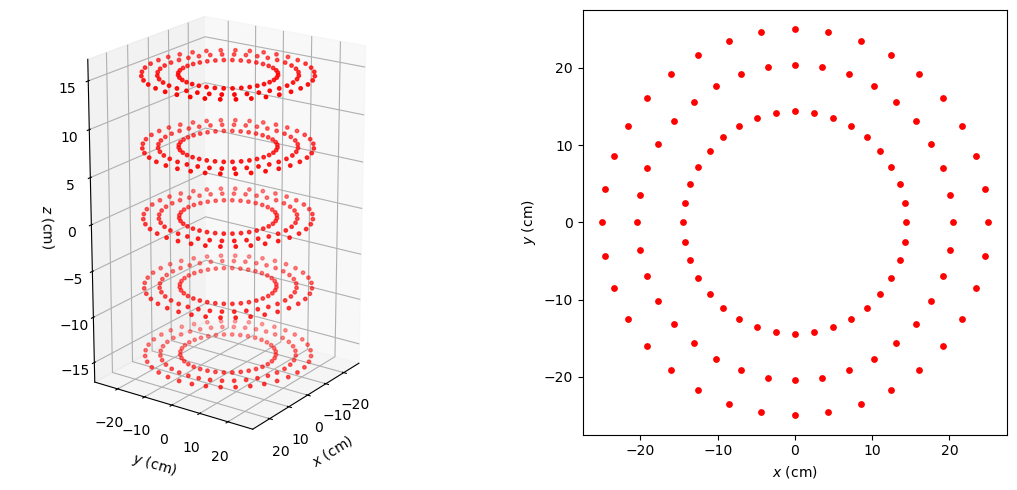

In [4]:
def plot_mapper_geometry(mapper_df):
    """ Plot the mapper measurement locations in 3D and the z = 0 plane"""
    xyz = 100*mapper_df[["x", "y", "z"]].to_numpy()
    sl = mapper_df[np.isclose(mapper_df["z"], 0)]

    fig = plt.figure(figsize=(11, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    ax2 = fig.add_subplot(122)

    ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], color="red", s=6)
    ax1.view_init(elev=20, azim=35)
    ax1.set_box_aspect((1, 1, 1.75))
    ax1.set(xlabel=r"$x$ (cm)", ylabel=r"$y$ (cm)", zlabel=r"$z$ (cm)")

    ax2.scatter(100*sl["x"], 100*sl["y"], color="red", s=15)
    ax2.set_aspect("equal")
    ax2.set(xlabel=r"$x$ (cm)", ylabel=r"$y$ (cm)")

    plt.tight_layout()

    plt.show()

plot_mapper_geometry(pinn_results_540['mapper_df'])

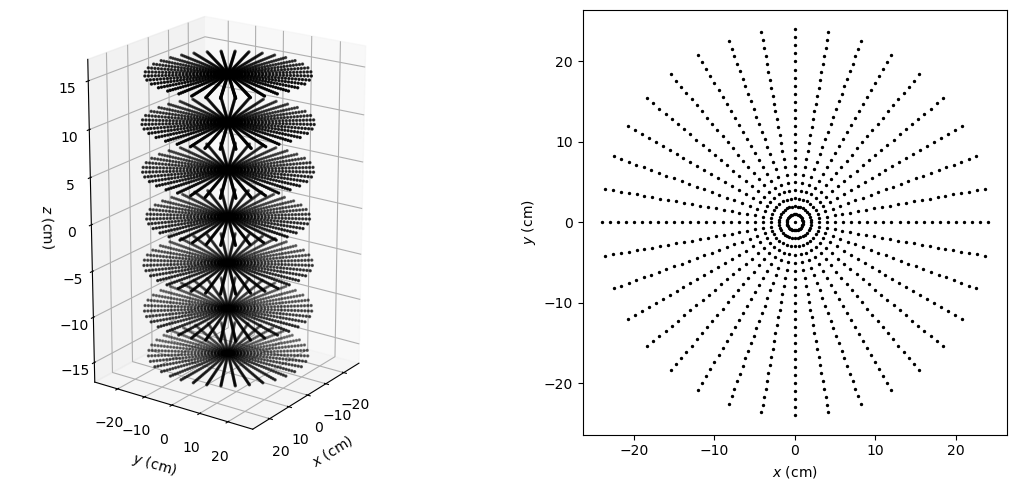

In [5]:
def plot_mapper_geometry(mapper_df):
    xyz = 100*mapper_df[["x", "y", "z"]].to_numpy()
    sl = mapper_df[np.isclose(mapper_df["z"], 0)]

    fig = plt.figure(figsize=(11, 5))
    ax1 = fig.add_subplot(121, projection="3d")
    ax2 = fig.add_subplot(122)

    ax1.scatter(xyz[:, 0], xyz[:, 1], xyz[:, 2], color="k", s=2)
    ax1.view_init(elev=20, azim=35)
    ax1.set_box_aspect((1, 1, 1.75))
    ax1.set(xlabel=r"$x$ (cm)", ylabel=r"$y$ (cm)", zlabel=r"$z$ (cm)")

    ax2.scatter(100*sl["x"], 100*sl["y"], color="k", s=2)
    ax2.set_aspect("equal")
    ax2.set(xlabel=r"$x$ (cm)", ylabel=r"$y$ (cm)")

    plt.tight_layout()
    plt.show()

plot_mapper_geometry(pinn_results_540['colloc_df'])

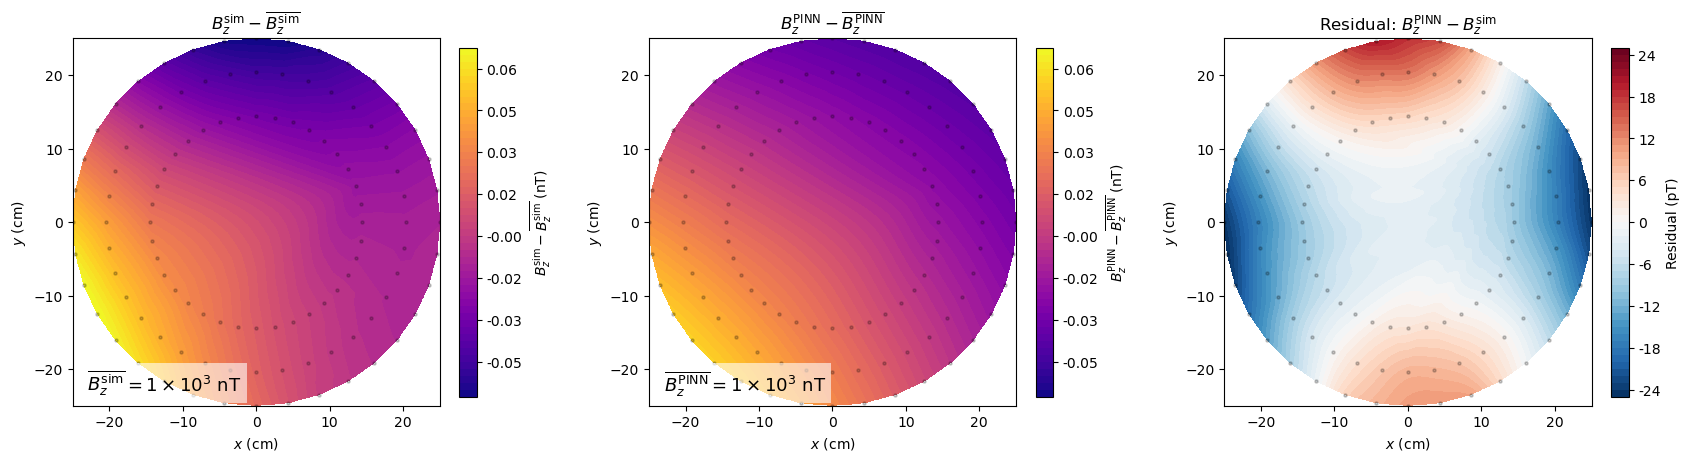

In [6]:
def plot_field_comparison(truth_df, pinn_df, component="bz", z_value=0, radius=0.25):

    """Plot the simulated field, PINN reconstruction, and residual at a selected z plane.
    z=0 is the where most crucial reason so z=0 is selected"""

    
    t = truth_df[np.isclose(truth_df.z, z_value)].sort_values(["x", "y"])
    p = pinn_df[np.isclose(pinn_df.z, z_value)].sort_values(["x", "y"])
    mt, mp = t[component].mean(), p[component].mean()

    g = np.linspace(-radius, radius, 900); X, Y = np.meshgrid(g, g)
    pts = (t.x, t.y); outside = X**2 + Y**2 > radius**2

    sim = griddata(pts, t[component] - mt, (X, Y), method="linear")
    pinn = griddata(pts, p[component] - mp, (X, Y), method="linear")
    res = griddata(pts, 1000*(p[component].values - t[component].values), (X, Y), method="cubic")

    for Z in (sim, pinn, res): Z[outside] = np.nan

    fmin = min(np.nanmin(sim), np.nanmin(pinn))
    fmax = max(np.nanmax(sim), np.nanmax(pinn))
    rmax = np.nanmax(np.abs(res)); b = component[-1]

    panels = [
        (sim, rf"$B_{b}^{{\rm sim}}-\overline{{B_{b}^{{\rm sim}}}}$",
         rf"$\overline{{B_{b}^{{\rm sim}}}}={mt/1000:.0f}\times10^{{3}}$ nT",
         "plasma", np.linspace(fmin, fmax, 51),
         rf"$B_{b}^{{\rm sim}}-\overline{{B_{b}^{{\rm sim}}}}$ (nT)", "%.2f"),

        (pinn, rf"$B_{b}^{{\rm PINN}}-\overline{{B_{b}^{{\rm PINN}}}}$",
         rf"$\overline{{B_{b}^{{\rm PINN}}}}={mp/1000:.0f}\times10^{{3}}$ nT",
         "plasma", np.linspace(fmin, fmax, 51),
         rf"$B_{b}^{{\rm PINN}}-\overline{{B_{b}^{{\rm PINN}}}}$ (nT)", "%.2f"),

        (res, rf"Residual: $B_{b}^{{\rm PINN}}-B_{b}^{{\rm sim}}$", "",
         "RdBu_r", np.linspace(-rmax, rmax, 51), "Residual (pT)", "%.0f") ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 4.5), constrained_layout=True)

    for ax, (Z, title, text, cmap, levels, label, fmt) in zip(axes, panels):
        im = ax.contourf(X*100, Y*100, Z, levels=levels, cmap=cmap)
        ax.scatter(t.x*100, t.y*100, s=5, c="k", alpha=0.2)
        ax.set(xlabel=r"$x$ (cm)", ylabel=r"$y$ (cm)", title=title, aspect="equal")
        if text:
            ax.text( 0.04, 0.04, text, transform=ax.transAxes, fontsize=13,  
                bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")  )

        fig.colorbar(im, ax=ax, label=label, shrink=0.95, format=fmt)

    plt.show()

plot_field_comparison(pinn_results_540['mapper_df'], pinn_results_540['prediction_df'])

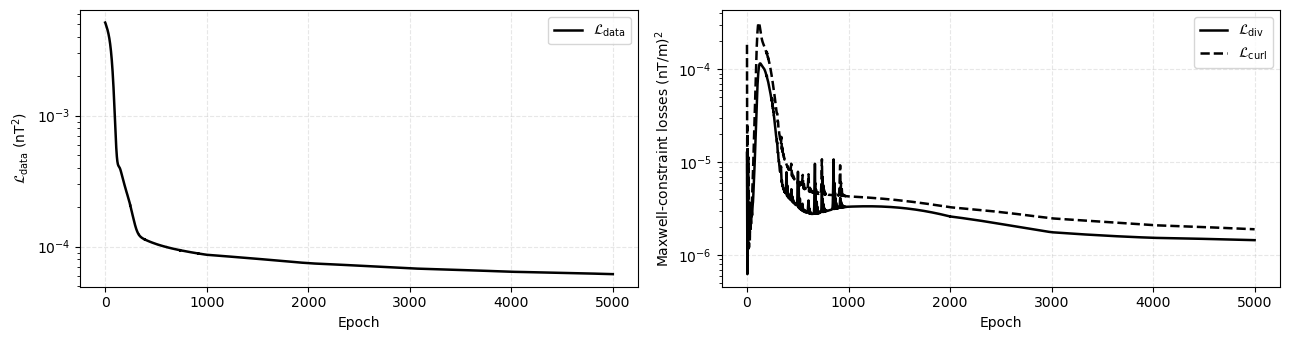

In [8]:


# Plot the data and Maxwell-constraint losses during PINN training.
loss = pinn_results_540['loss_history']

data, div, curl = [np.asarray(loss[k]) for k in ["mse", "div", "curl"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 3.5))

ax1.semilogy(data, "k-", lw=1.8, label=r"$\mathcal{L}_{\rm data}$")
ax1.set(xlabel="Epoch", ylabel=r"$\mathcal{L}_{\rm data}$ (nT$^2$)")
ax1.legend()

ax2.semilogy(div, "k-", lw=1.8, label=r"$\mathcal{L}_{\rm div}$")
ax2.semilogy(curl, "k--", lw=1.8, label=r"$\mathcal{L}_{\rm curl}$")
ax2.set(xlabel="Epoch", ylabel=r"Maxwell-constraint losses $(\mathrm{nT/m})^2$")
ax2.legend()

for ax in (ax1, ax2): ax.grid(alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

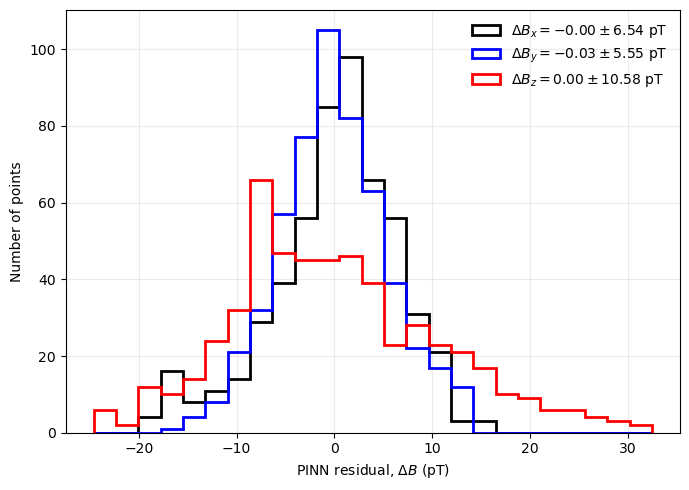

In [9]:

# Plot the  histogram residual distributions of the PINN-reconstructed magnetic-field components.
components = ["bx", "by", "bz"]
symbols = ["x", "y", "z"]
colors = ["black", "blue", "red"]
scale = 1000

mapper_df = pinn_results_540["mapper_df"]
pinn_df= pinn_results_540["prediction_df"]

pinn_res = scale * (pinn_df[components].to_numpy() -mapper_df[components].to_numpy())

fig, ax = plt.subplots(figsize=(7, 5))

bins = np.histogram_bin_edges(pinn_res.ravel(), bins=25)

for i, (symbol, color) in enumerate(zip(symbols, colors)):
    mean = pinn_res[:, i].mean()
    std = pinn_res[:, i].std(ddof=1)

    ax.hist(pinn_res[:, i], bins=bins,  histtype="step", color=color, linewidth=2, label=rf"$\Delta B_{symbol}={mean:.2f}\pm{std:.2f}$ pT" )

ax.set_xlabel(r"PINN residual, $\Delta B$ (pT)")
ax.set_ylabel("Number of points")
ax.grid(alpha=0.25)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

In [11]:
# Fit 540 measurement points using spherical harmonics up to l_max = 3,
# compute the glm coefficients, and reconstruct the field.
# Replace 540 with 135 or 1080 to use a different measurement configuration.

sh_prediction_540_df, sh_glm_540_df, sh_linear_gradient_540_df = ( sh.spherical_harmonics(540, l_max=3))

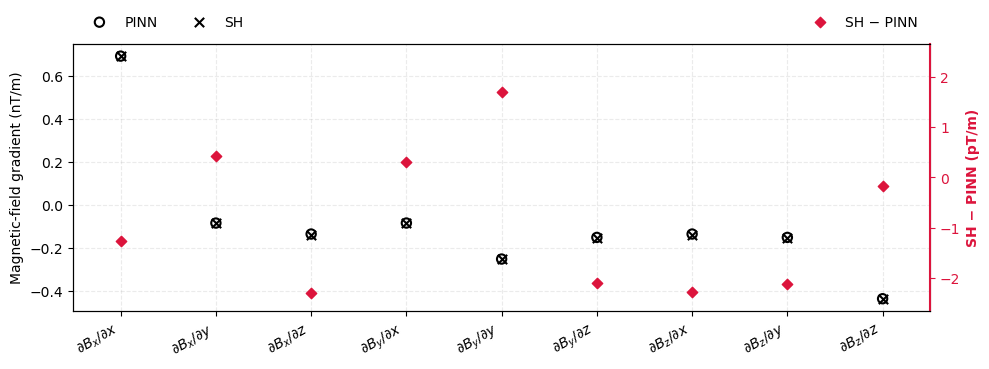

In [13]:

pinn_linear_gradient_540_df= pinn_results_540['linear_gradient']
def plot_linear_gradient_comparison(pinn_df, sh_df):
    """ Compare the nine first-order magnetic-field gradients obtained using the PINN and spherical harmonics."""
    
    x = np.arange(9); crimson = "crimson"
    labels = [r"$\partial B_x/\partial x$", r"$\partial B_x/\partial y$", r"$\partial B_x/\partial z$",
        r"$\partial B_y/\partial x$", r"$\partial B_y/\partial y$", r"$\partial B_y/\partial z$",
        r"$\partial B_z/\partial x$", r"$\partial B_z/\partial y$", r"$\partial B_z/\partial z$"]

    pinn = pinn_df["mean"].to_numpy()
    sh = sh_df.iloc[0].to_numpy()
    difference = 1000*(sh-pinn) # right side y axis

    fig,ax1 = plt.subplots(figsize=(10,3.8)); ax2 = ax1.twinx()

    ax1.scatter(x,pinn,s=45,facecolors="none",edgecolors="black",
                marker="o",linewidth=1.5,label="PINN",zorder=4)
    ax1.scatter(x,sh,s=45,color="black",marker="x",
                linewidth=1.5,label="SH",zorder=5)
    ax2.scatter(x,difference,s=28,color=crimson,marker="D",
                label="SH − PINN",zorder=3)

    dmax = 1.15*np.max(np.abs(difference)); ax2.set_ylim(-dmax,dmax)

    ax1.set_ylabel("Magnetic-field gradient (nT/m)")
    ax2.set_ylabel("SH − PINN (pT/m)",color=crimson,fontweight="bold")
    ax2.tick_params(axis="y",colors=crimson)
    ax2.spines["right"].set_color(crimson)
    ax2.spines["right"].set_linewidth(1.5)

    ax1.set_xticks(x); ax1.set_xticklabels(labels,rotation=30,ha="right")
    ax1.set_xlim(-.5,8.5); ax1.grid(axis="both",ls="--",alpha=.25)

    ax1.legend(loc="lower left",bbox_to_anchor=(0,1.01),frameon=False,ncol=2)
    ax2.legend(loc="lower right",bbox_to_anchor=(1,1.01),frameon=False,labelcolor="black")

    fig.tight_layout()
    plt.show()
plot_linear_gradient_comparison( pinn_linear_gradient_540_df,sh_linear_gradient_540_df)

In [14]:
truth_540_df = pinn_results_540["mapper_df"]
pinn_prediction_540_df = pinn_results_540["prediction_df"]

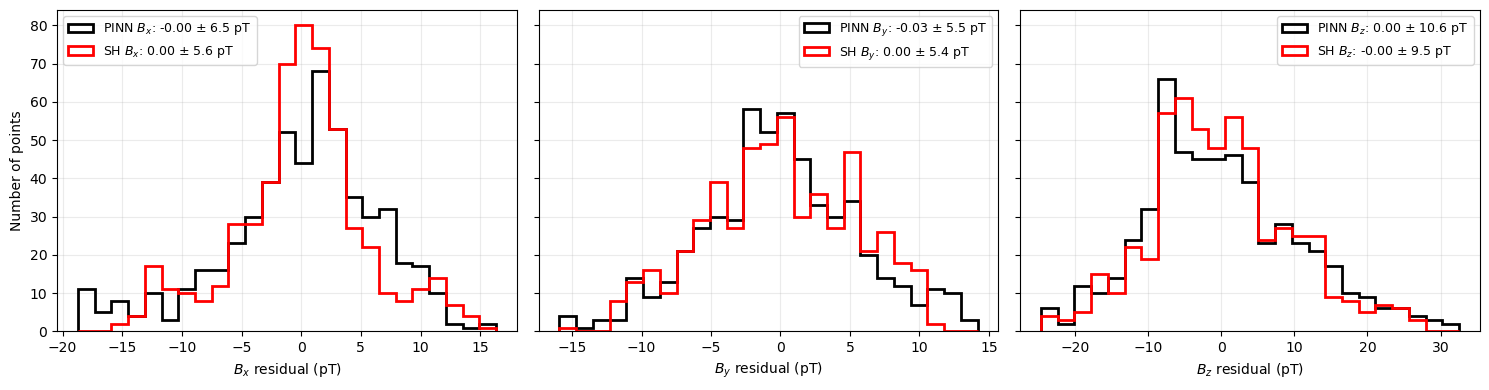

In [15]:
def plot_pinn_sh_residuals(pinn_df, sh_df, truth_df, bins=25):
    components = ["bx", "by", "bz"]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, component in zip(axes, components):
        b = component[-1]
        pinn_res = 1000*(pinn_df[component].to_numpy() - truth_df[component].to_numpy())
        sh_res = 1000*(sh_df[component].to_numpy() - truth_df[component].to_numpy())

        edges = np.linspace(min(pinn_res.min(), sh_res.min()),
                            max(pinn_res.max(), sh_res.max()), bins + 1)

        ax.hist(pinn_res, bins=edges, histtype="step", lw=2, color="black",
                label=rf"PINN $B_{b}$: {pinn_res.mean():.2f} $\pm$ {pinn_res.std():.1f} pT")

        ax.hist(sh_res, bins=edges, histtype="step", lw=2, color="red",
                label=rf"SH $B_{b}$: {sh_res.mean():.2f} $\pm$ {sh_res.std():.1f} pT")

        ax.set_xlabel(rf"$B_{b}$ residual (pT)")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=9)

    axes[0].set_ylabel("Number of points")
    plt.tight_layout()
    plt.show()
plot_pinn_sh_residuals( pinn_prediction_540_df, sh_prediction_540_df,truth_540_df)

In [16]:

# Train the PINN and reconstruct the uniform magnetic field using 135 measurement points.
pinn_results_135 = pinn.run_uniform_field(135)

PINN training: 100%|███████████████████████| 5000/5000 [00:42<00:00, 116.71it/s]

Saved results: /Users/prakashadhikari/Desktop/PINN-Magnetic-Field-Reconstruction/results/pinn_135/results.pkl


In [17]:

# Train the PINN and reconstruct the uniform magnetic field using 1080 measurement points.
pinn.run_uniform_field(1080)

PINN training: 100%|███████████████████████| 5000/5000 [00:45<00:00, 109.31it/s]


Saved results: /Users/prakashadhikari/Desktop/PINN-Magnetic-Field-Reconstruction/results/pinn_1080/results.pkl


In [18]:
result_file_135 = project_dir / "results" / "pinn_135" / "results.pkl"
result_file_1080 = project_dir / "results" / "pinn_1080" / "results.pkl"

with open(result_file_135, "rb") as f:
    pinn_results_135 = pickle.load(f)

with open(result_file_1080, "rb") as f:
    pinn_results_1080 = pickle.load(f)

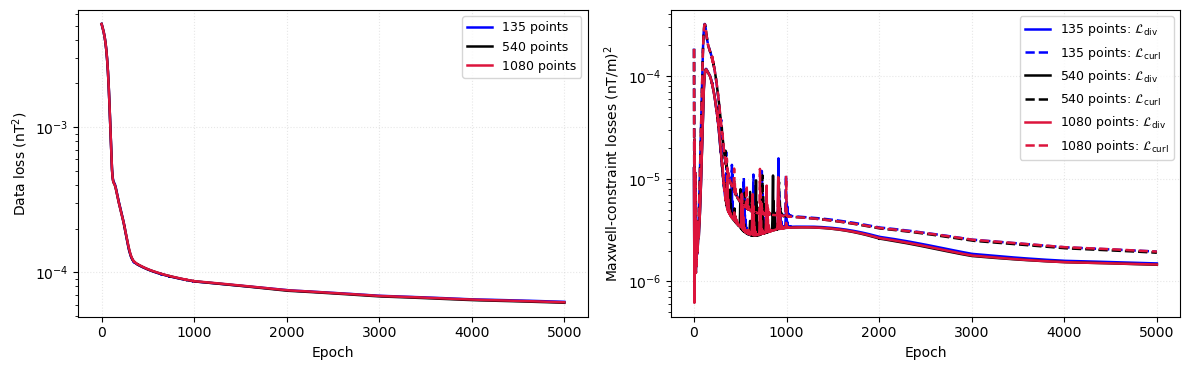

In [19]:

# Compare the PINN training losses for the 135, 540 , and 1080 point measurement configurations.

loss_135  = pinn_results_135["loss_history"]
loss_540  = pinn_results_540["loss_history"]
loss_1080 = pinn_results_1080["loss_history"]


def plot_losses(loss_135, loss_540, loss_1080):
    losses = {
        "135 points": (loss_135, "blue"),
        "540 points": (loss_540, "black"),
        "1080 points": (loss_1080, "crimson") }

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.8))

    for label, (loss, color) in losses.items():
        ax1.semilogy(loss["mse"], color=color, lw=1.8, label=label)

        ax2.semilogy(loss["div"], color=color, lw=1.8, ls="-",
                     label=rf"{label}: $\mathcal{{L}}_{{\rm div}}$")
        ax2.semilogy(loss["curl"], color=color, lw=1.8, ls="--",
                     label=rf"{label}: $\mathcal{{L}}_{{\rm curl}}$")

    ax1.set(xlabel="Epoch", ylabel=r"Data loss (nT$^2$)")

    ax2.set(xlabel="Epoch", ylabel=r"Maxwell-constraint losses $(\mathrm{nT/m})^2$")


    for ax in (ax1, ax2):
        ax.grid(alpha=0.3, linestyle=":")
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

plot_losses(loss_135, loss_540, loss_1080)

In [24]:
def make_metrics_table(pinn_results_135, pinn_results_540, pinn_results_1080):
    """Compare PINN residuals (pT) and Maxwell metrics (pT/m) for 135, 540 and 1080 measurement points."""
    results = {135: pinn_results_135, 540: pinn_results_540, 1080: pinn_results_1080}
    rows = []

    for n, result in results.items():
        df = result["metrics_df"]
        rows.append({
            "Points": n,
            "∇·B (pT/m)": f'{1000*df["div_B_mean"].iloc[0]:.1f} ± {1000*df["div_B_std"].iloc[0]:.1f}',
            "(∇×B)x (pT/m)": f'{1000*df["curl_x_mean"].iloc[0]:.1f} ± {1000*df["curl_x_std"].iloc[0]:.1f}',
            "(∇×B)y (pT/m)": f'{1000*df["curl_y_mean"].iloc[0]:.1f} ± {1000*df["curl_y_std"].iloc[0]:.1f}',
            "(∇×B)z (pT/m)": f'{1000*df["curl_z_mean"].iloc[0]:.1f} ± {1000*df["curl_z_std"].iloc[0]:.1f}',
            "|∇×B| (pT/m)": f'{1000*df["curl_mag_mean"].iloc[0]:.1f} ± {1000*df["curl_mag_std"].iloc[0]:.1f}',
            "σBx (pT)": f'{1000*df["bx_std"].iloc[0]:.1f}',
            "σBy (pT)": f'{1000*df["by_std"].iloc[0]:.1f}',
            "σBz (pT)": f'{1000*df["bz_std"].iloc[0]:.1f}'
        })

    return pd.DataFrame(rows).set_index("Points")

comparison_table = make_metrics_table(pinn_results_135, pinn_results_540, pinn_results_1080)
comparison_table

,∇·B (pT/m),(∇×B)x (pT/m),(∇×B)y (pT/m),(∇×B)z (pT/m),|∇×B| (pT/m),σBx (pT),σBy (pT),σBz (pT)
Points,,,,,,,,
135,-0.3 ± 1.8,0.0 ± 0.8,0.0 ± 1.4,0.1 ± 1.8,1.9 ± 1.6,6.6,5.6,10.7
540,-0.3 ± 2.0,0.0 ± 0.9,0.0 ± 1.5,0.1 ± 1.9,1.9 ± 1.7,6.5,5.5,10.6
1080,-0.3 ± 2.0,0.0 ± 0.9,0.0 ± 1.5,0.1 ± 1.9,1.9 ± 1.7,6.6,5.6,10.6
